In [36]:
import os

import scipy
import pandas as pd
import matplotlib.pyplot as plt

In [37]:
# Style and plot settings
plt.style.use("ggplot")

COLOR = "red"
ALPHA_MEAN = 0.9
ALPHA_STD = 0.1
AVG_FILTER_SIZE = 5

In [38]:
def load_data(env_id: str) -> pd.DataFrame:
    files = [x for x in os.listdir() if env_id in x and x.endswith(".csv")]
    dfs = [pd.read_csv(f) for f in files]
    
    df_out = pd.DataFrame() 
    df_out["t"] = dfs[0]["t"]

    stacked_means = pd.concat([df["average_return"] for df in dfs], axis=1)
    df_out["average_return"] = stacked_means.mean(axis=1)  
    df_out["std_return"] = stacked_means.std(axis=1, ddof=1)  

    return df_out

## LunarLander-v3

In [39]:
data = load_data("LunarLander-v3")
data.head(-1)

,t,average_return,std_return
0,65536,-511.794080,183.580723
1,131072,-173.413859,101.546690
2,196608,-182.930255,113.302373
3,262144,-128.935057,120.913538
4,327680,-210.582754,233.312879
5,393216,-287.598080,257.167612
6,458752,-305.673315,297.688404
7,524288,-201.855677,121.454797
8,589824,-210.022096,164.798815
9,655360,-155.350874,119.078687


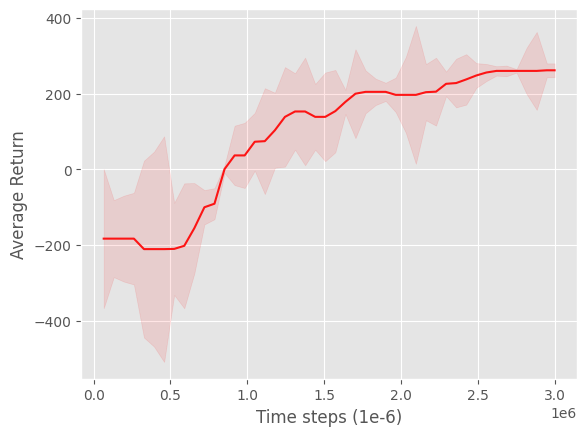

In [40]:
t = data["t"]
mean = data["average_return"]
mean = scipy.ndimage.median_filter(data["average_return"], size=AVG_FILTER_SIZE)
std = data["std_return"]
lower = mean - std
upper = mean + std

fig, ax = plt.subplots()
ax.plot(t, mean, color=COLOR, alpha=ALPHA_MEAN)
ax.fill_between(t, lower, upper, alpha=ALPHA_STD, color=COLOR)
ax.set_xlabel("Time steps (1e-6)")
ax.set_ylabel("Average Return")
plt.show()



## BipedalWalker-v3

In [41]:
data = load_data("BipedalWalker-v3")
data.head(-1)

,t,average_return,std_return
0,65536,-109.553309,15.575915
1,131072,-21.435462,3.583415
2,196608,-23.444630,0.259297
3,262144,-17.377632,9.646893
4,327680,-21.126035,5.255771
5,393216,-31.011765,0.288780
6,458752,-74.759848,60.158675
7,524288,-35.952532,17.587823
8,589824,-46.265867,30.235210
9,655360,-54.284021,29.417060


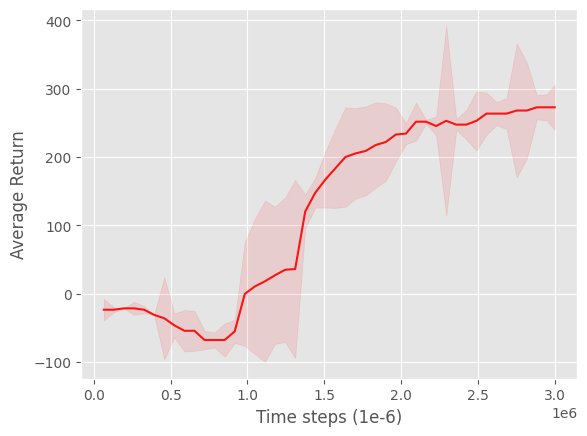

In [42]:
t = data["t"]
mean = data["average_return"]
mean = scipy.ndimage.median_filter(data["average_return"], size=AVG_FILTER_SIZE)
std = data["std_return"]
lower = mean - std
upper = mean + std

fig, ax = plt.subplots()
ax.plot(t, mean, color=COLOR, alpha=ALPHA_MEAN)
ax.fill_between(t, lower, upper, alpha=ALPHA_STD, color=COLOR)
ax.set_xlabel("Time steps (1e-6)")
ax.set_ylabel("Average Return")
plt.show()

